First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Selected Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction

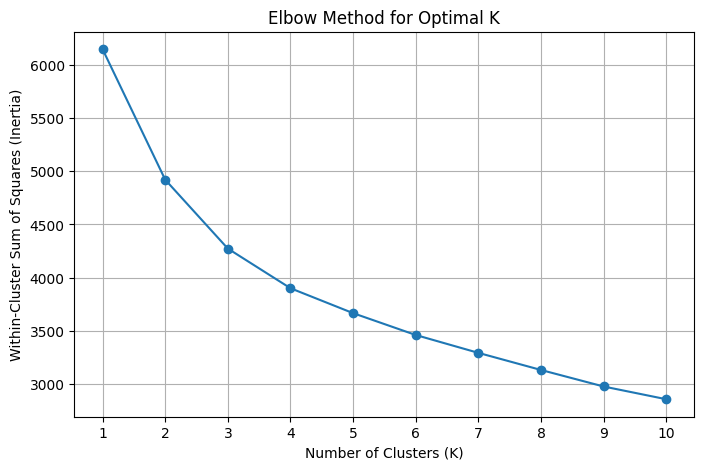


Selected number of clusters (K): 2

Cluster assignments:
Cluster
0    341
1    427
Name: count, dtype: int64

Silhouette Score: 0.2052
Interpretation: Poorly separated clusters.

PCA explained variance ratio:
[0.29817668 0.18752573]

Total variance explained by first two components: 48.57 %

PCA Component Loadings:
                               PC1       PC2
Pregnancies               0.279707  0.569385
Glucose                   0.432168 -0.073939
BloodPressure             0.356124  0.192996
SkinThickness             0.403140 -0.288188
Insulin                   0.359211 -0.218764
BMI                       0.403325 -0.378360
DiabetesPedigreeFunction  0.158201 -0.264107
Age                       0.359049  0.537836

Variables contributing most to PC1:
Glucose                     0.432168
BMI                         0.403325
SkinThickness               0.403140
Insulin                     0.359211
Age                         0.359049
BloodPressure               0.356124
Pregnancies       

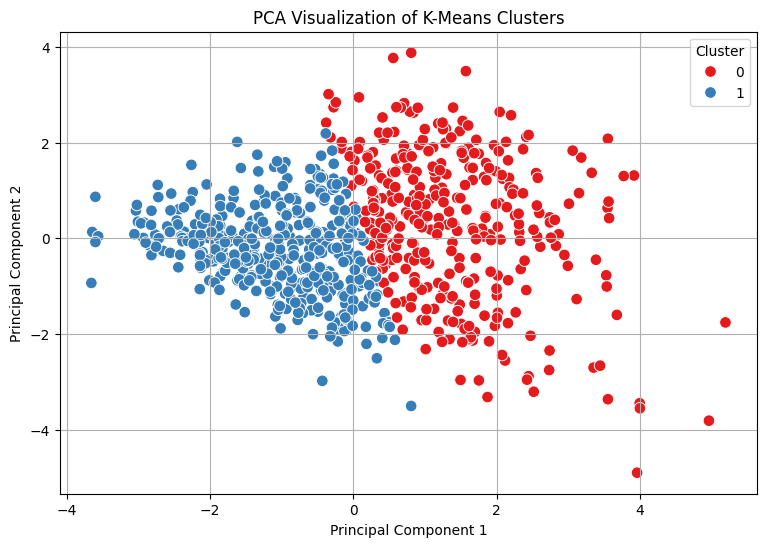

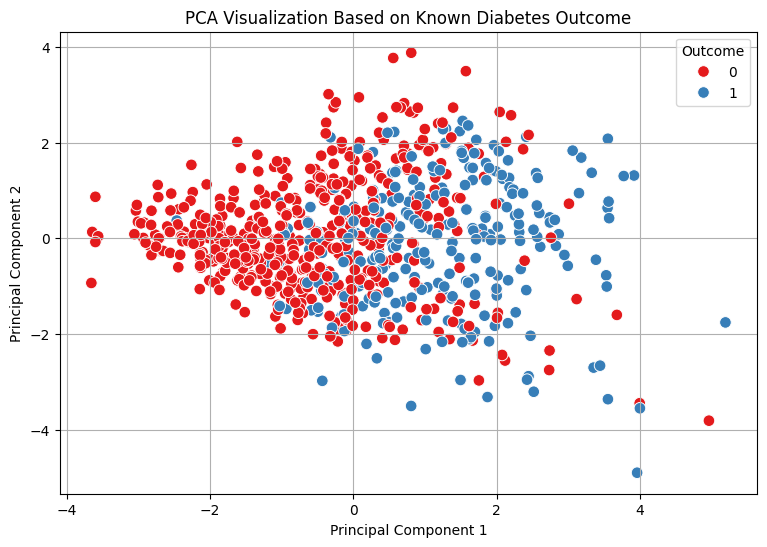


Cluster vs Outcome:
Outcome    0    1
Cluster          
0        136  205
1        364   63

Percentage of Outcome in Each Cluster:
Outcome      0      1
Cluster              
0        39.88  60.12
1        85.25  14.75

Adjusted Rand Index (ARI): 0.2303

FINAL SUMMARY
Selected K: 2
Silhouette Score: 0.2052
Variance explained by PC1 + PC2: 48.57 %

Most important variables for PC1:
Glucose          0.432168
BMI              0.403325
SkinThickness    0.403140
Name: PC1, dtype: float64

Most important variables for PC2:
Pregnancies    0.569385
Age            0.537836
BMI            0.378360
Name: PC2, dtype: float64

Cluster vs Outcome:
Outcome    0    1
Cluster          
0        136  205
1        364   63

Adjusted Rand Index: 0.2303


In [3]:
# ============================================================
# PIMA INDIANS DIABETES DATASET
# K-MEANS CLUSTERING + PCA
# ============================================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

# ============================================================
# 2. Load Dataset
# ============================================================

# Upload diabetes.csv to Google Colab first
df = pd.read_csv("diabetes.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

# ============================================================
# 3. Select Numerical Features
# ============================================================

# Outcome is excluded because this is UNSUPERVISED learning.
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[features].copy()

print("\nSelected Features:")
print(X.columns.tolist())

# Save Outcome only for comparison after clustering
outcome = df["Outcome"]

# ============================================================
# 4. Handle Invalid Values
# ============================================================

# In this dataset, zero values in these medical attributes
# are considered invalid/missing.
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[invalid_columns] = X[invalid_columns].replace(0, np.nan)

print("\nMissing values after replacing invalid zeros:")
print(X.isnull().sum())

# ============================================================
# 5. Handle Missing Values using Median
# ============================================================

imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("\nMissing values after median imputation:")
print(X_imputed.isnull().sum())

# ============================================================
# 6. Standardize Features
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

print("\nData standardized successfully.")

# ============================================================
# 7. ELBOW METHOD
# ============================================================

inertia = []

# Test different values of K
K_values = range(1, 11)

for k in K_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    K_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.xticks(K_values)
plt.grid()
plt.show()

# ============================================================
# 8. Select K
# ============================================================

# For this dataset, K=2 is a reasonable choice.
# The Elbow graph should be inspected to confirm.

optimal_k = 2

print("\nSelected number of clusters (K):", optimal_k)

# ============================================================
# 9. Apply K-Means Clustering
# ============================================================

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df["Cluster"] = clusters

print("\nCluster assignments:")
print(df["Cluster"].value_counts().sort_index())

# ============================================================
# 10. Silhouette Score
# ============================================================

sil_score = silhouette_score(
    X_scaled,
    clusters
)

print("\nSilhouette Score:", round(sil_score, 4))

if sil_score >= 0.70:
    print("Interpretation: Strong and well-separated clusters.")
elif sil_score >= 0.50:
    print("Interpretation: Reasonably good clustering.")
elif sil_score >= 0.25:
    print("Interpretation: Weak or moderate clustering.")
else:
    print("Interpretation: Poorly separated clusters.")

# ============================================================
# 11. PCA - Reduce to 2 Dimensions
# ============================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal variance explained by first two components:",
    round(sum(pca.explained_variance_ratio_) * 100, 2),
    "%"
)

# ============================================================
# 12. PCA Component Loadings
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

print("\nPCA Component Loadings:")
print(loadings)

# Find variables contributing most to PC1 and PC2
print("\nVariables contributing most to PC1:")
print(
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
)

print("\nVariables contributing most to PC2:")
print(
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
)

# ============================================================
# 13. PCA DataFrame
# ============================================================

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters
pca_df["Outcome"] = outcome.values

print("\nPCA Data:")
print(pca_df.head())

# ============================================================
# 14. PCA Visualization using Clusters
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=70
)

plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

# ============================================================
# 15. PCA Visualization using Known Outcome
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Outcome",
    palette="Set1",
    s=70
)

plt.title("PCA Visualization Based on Known Diabetes Outcome")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

# ============================================================
# 16. Compare Clusters with Outcome
# ============================================================

comparison = pd.crosstab(
    df["Cluster"],
    df["Outcome"]
)

print("\nCluster vs Outcome:")
print(comparison)

# ============================================================
# 17. Calculate Percentage of Diabetes in Each Cluster
# ============================================================

cluster_outcome_percentage = pd.crosstab(
    df["Cluster"],
    df["Outcome"],
    normalize="index"
) * 100

print("\nPercentage of Outcome in Each Cluster:")
print(cluster_outcome_percentage.round(2))

# ============================================================
# 18. Adjusted Rand Index
# ============================================================

ari = adjusted_rand_score(
    outcome,
    clusters
)

print("\nAdjusted Rand Index (ARI):", round(ari, 4))

# ============================================================
# 19. Final Summary
# ============================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print("Selected K:", optimal_k)

print("Silhouette Score:", round(sil_score, 4))

print(
    "Variance explained by PC1 + PC2:",
    round(sum(pca.explained_variance_ratio_) * 100, 2),
    "%"
)

print("\nMost important variables for PC1:")
print(
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head(3)
)

print("\nMost important variables for PC2:")
print(
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head(3)
)

print("\nCluster vs Outcome:")
print(comparison)

print("\nAdjusted Rand Index:", round(ari, 4))